参考HAGI++绘制出sequence gaze 的(yaw, pitch) 曲线图

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('default')

In [2]:
adt_dataset_path = "/mnt/d/SparseGaze/ADT-Gaze-structured/sequences"
sequence_name = "Apartment_release_decoration_skeleton_seq131_M1292"
gaze_data_path = f"{adt_dataset_path}/{sequence_name}/gaze/gaze_samples.csv"
head_data_path = f"{adt_dataset_path}/{sequence_name}/head/head_samples.csv"

In [3]:
gaze_data = pd.read_csv(gaze_data_path)
head_data = pd.read_csv(head_data_path)

In [4]:
gaze_data['yaw_rad']

0      -0.128318
1      -0.131702
2      -0.098323
3      -0.036608
4      -0.036774
          ...   
2835    0.417415
2836    0.406272
2837    0.376561
2838    0.296280
2839    0.239482
Name: yaw_rad, Length: 2840, dtype: float64

Text(0, 0.5, 'Angle (degrees)')

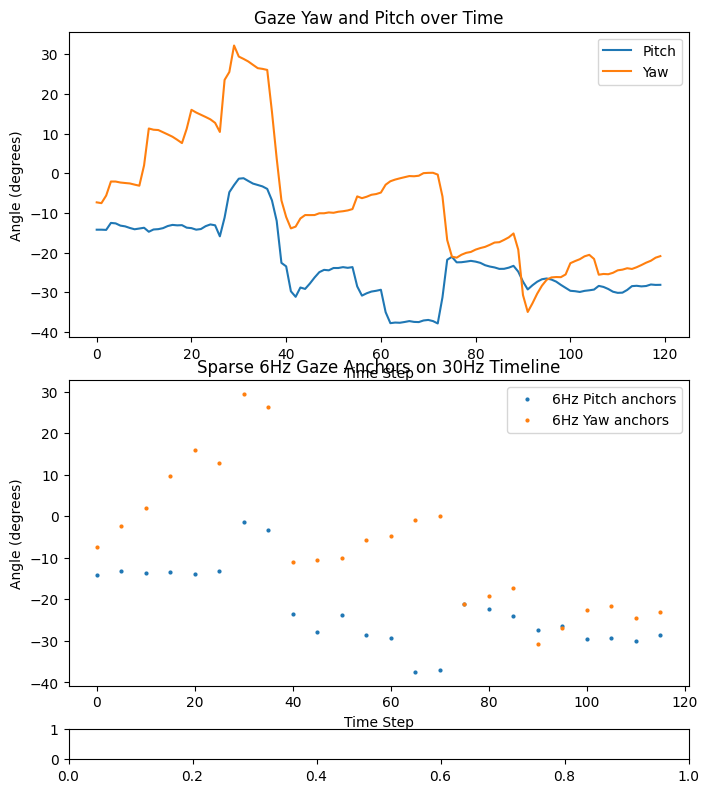

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9.45), gridspec_kw={'height_ratios': [1.0, 1.0, 0.1]})
pitch_color = "#1f77b4"  # 蓝色
yaw_color = '#ff7f0e'    # 橙色
missing_color = '#CCCCCC'  # 灰色用于缺失数据
imputed_color = '#2ca02c'

pitch = gaze_data['pitch_rad'].iloc[:120] / np.pi * 180  # 转换为度
yaw = gaze_data['yaw_rad'].iloc[:120] / np.pi * 180  # 转换为度
time_step = np.arange(len(pitch))

ax = axes[0]

ax.plot(time_step, pitch, color=pitch_color, label='Pitch')
ax.plot(time_step, yaw, color=yaw_color, label='Yaw')
ax.legend()
ax.set_title('Gaze Yaw and Pitch over Time')
ax.set_xlabel('Time Step')
ax.set_ylabel('Angle (degrees)')
# ax.grid(True)

# 绘制降采样之后的数据，目标频率设置为6Hz吧
original_freq = 30  # 原始频率
target_freq = 6     # 目标频率
downsample_factor = original_freq // target_freq

ax = axes[1]
sparse_pitch = np.full(len(pitch), np.nan)
sparse_yaw = np.full(len(yaw), np.nan)

anchor_idx = np.arange(0, len(pitch), downsample_factor)
sparse_pitch[anchor_idx] = pitch.iloc[anchor_idx].to_numpy()
sparse_yaw[anchor_idx] = yaw.iloc[anchor_idx].to_numpy()

# 只画 anchor 点，不连线
ax.plot(
    time_step,
    sparse_pitch,
    color=pitch_color,
    marker='o',
    markersize=2,
    linestyle='None',
    label='6Hz Pitch anchors',
)

ax.plot(
    time_step,
    sparse_yaw,
    color=yaw_color,
    marker='o',
    markersize=2,
    linestyle='None',
    label='6Hz Yaw anchors',
)

ax.legend()
ax.set_title('Sparse 6Hz Gaze Anchors on 30Hz Timeline')
ax.set_xlabel('Time Step')
ax.set_ylabel('Angle (degrees)')